In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

project_root = '/Users/nicoleotero/Desktop/GLP1 research project/glp1-market-impact-analysis'

events = {
    'wegovy_approved':   '2021-06-04',
    'mounjaro_approved': '2022-05-13',
    'zepbound_approved': '2023-11-08'
}

sector_map = {
    'LLY':   'GLP-1 Makers',
    'NVO':   'GLP-1 Makers',
    'DXCM':  'Diabetes Devices',
    'PODD':  'Diabetes Devices',
    'KHC':   'Food & Beverage',
    'NSRGY': 'Food & Beverage',
    'PEP':   'Food & Beverage',
    'MCD':   'Fast Food',
    'YUM':   'Fast Food',
    'PLNT':  'Fitness',
    'ISRG':  'Surgical',
    'SPY':   'Market Benchmark'
}

print("Libraries loaded successfully")

Libraries loaded successfully


In [18]:
raw_path = os.path.join(project_root, 'data', 'raw', 'close_prices_raw.csv')
spy_path = os.path.join(project_root, 'data', 'raw', 'spy_benchmark.csv')

prices = pd.read_csv(raw_path, index_col=0, parse_dates=True)
spy = pd.read_csv(spy_path, index_col=0, parse_dates=True)

spy.columns = ['SPY']
all_prices = pd.concat([prices, spy], axis=1)

print("Data loaded successfully")
print(f"Shape: {all_prices.shape}")
print(f"Tickers: {all_prices.columns.tolist()}")
print(f"Date range: {all_prices.index[0].date()} to {all_prices.index[-1].date()}")

Data loaded successfully
Shape: (1885, 12)
Tickers: ['DXCM', 'ISRG', 'KHC', 'LLY', 'MCD', 'NSRGY', 'NVO', 'PEP', 'PLNT', 'PODD', 'YUM', 'SPY']
Date range: 2019-01-02 to 2026-07-02


In [19]:
wegovy_date = '2021-06-04'
post_wegovy = all_prices[all_prices.index >= wegovy_date].copy()
normalised = post_wegovy.div(post_wegovy.iloc[0]) * 100

print("=== WHERE EACH STOCK IS TODAY vs WEGOVY APPROVAL DATE ===")
print("(100 = same price, 200 = doubled, 50 = halved)\n")

latest = normalised.iloc[-1].sort_values(ascending=False).round(2)
for ticker, value in latest.items():
    sector = sector_map[ticker]
    change = value - 100
    direction = "▲" if change > 0 else "▼"
    print(f"{ticker:<6} {direction} {value:>7.1f}  ({change:+.1f}%)  [{sector}]")

=== WHERE EACH STOCK IS TODAY vs WEGOVY APPROVAL DATE ===
(100 = same price, 200 = doubled, 50 = halved)

SPY    ▲   189.2  (+89.2%)  [Market Benchmark]
DXCM   ▼     nan  (+nan%)  [Diabetes Devices]
ISRG   ▼     nan  (+nan%)  [Surgical]
KHC    ▼     nan  (+nan%)  [Food & Beverage]
LLY    ▼     nan  (+nan%)  [GLP-1 Makers]
MCD    ▼     nan  (+nan%)  [Fast Food]
NSRGY  ▼     nan  (+nan%)  [Food & Beverage]
NVO    ▼     nan  (+nan%)  [GLP-1 Makers]
PEP    ▼     nan  (+nan%)  [Food & Beverage]
PLNT   ▼     nan  (+nan%)  [Fitness]
PODD   ▼     nan  (+nan%)  [Diabetes Devices]
YUM    ▼     nan  (+nan%)  [Fast Food]


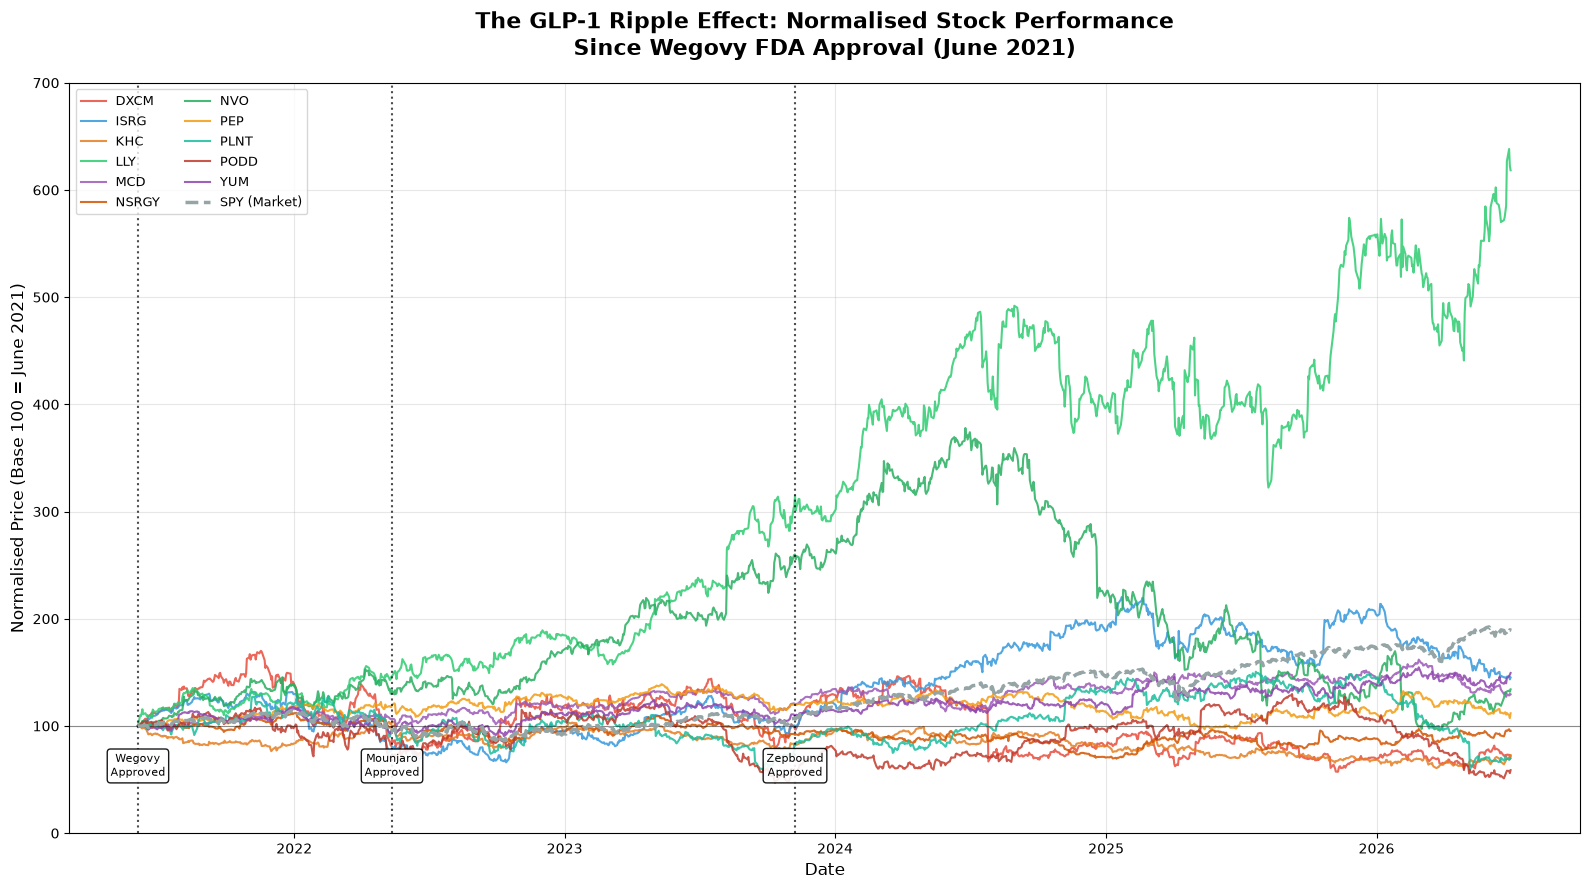

Chart saved!


In [20]:
sector_colours = {
    'LLY':   '#2ecc71',
    'NVO':   '#27ae60',
    'DXCM':  '#e74c3c',
    'PODD':  '#c0392b',
    'KHC':   '#e67e22',
    'NSRGY': '#d35400',
    'PEP':   '#f39c12',
    'MCD':   '#9b59b6',
    'YUM':   '#8e44ad',
    'PLNT':  '#1abc9c',
    'ISRG':  '#3498db',
    'SPY':   '#95a5a6',
}

fig, ax = plt.subplots(figsize=(16, 9))

for ticker in normalised.columns:
    if ticker == 'SPY':
        ax.plot(normalised.index, normalised[ticker],
                color=sector_colours[ticker],
                linewidth=2.5, linestyle='--',
                label='SPY (Market)', zorder=5)
    else:
        ax.plot(normalised.index, normalised[ticker],
                color=sector_colours[ticker],
                linewidth=1.5, alpha=0.85,
                label=ticker)

event_labels = {
    'wegovy_approved':   'Wegovy\nApproved',
    'mounjaro_approved': 'Mounjaro\nApproved',
    'zepbound_approved': 'Zepbound\nApproved'
}

for event, date in events.items():
    ax.axvline(x=pd.Timestamp(date), color='black',
               linewidth=1.5, linestyle=':', alpha=0.7)
    ax.text(pd.Timestamp(date), 50,
            event_labels[event], fontsize=8,
            ha='center', va='bottom',
            bbox=dict(boxstyle='round,pad=0.3',
                     facecolor='white', edgecolor='black', alpha=0.9))

ax.axhline(y=100, color='black', linewidth=0.8, alpha=0.4)
ax.set_ylim(0, 700)
ax.set_title('The GLP-1 Ripple Effect: Normalised Stock Performance\nSince Wegovy FDA Approval (June 2021)',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Normalised Price (Base 100 = June 2021)', fontsize=12)
ax.legend(loc='upper left', fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()

os.makedirs(os.path.join(project_root, 'visualizations'), exist_ok=True)
chart_path = os.path.join(project_root, 'visualizations', 'glp1_normalised_performance.png')
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

=== CORRELATION WITH LLY (post Wegovy approval) ===
(1.0 = moves in sync, 0 = no relationship, -1.0 = moves opposite)

SPY    +0.897  █████████████████     [Market Benchmark]
YUM    +0.843  ████████████████      [Fast Food]
ISRG   +0.822  ████████████████      [Surgical]
MCD    +0.818  ████████████████      [Fast Food]
NVO    +0.352  ███████               [GLP-1 Makers]
PLNT   +0.223  ████                  [Fitness]
PEP    +0.041                        [Food & Beverage]
PODD   -0.261  █████                 [Diabetes Devices]
KHC    -0.606  ████████████          [Food & Beverage]
DXCM   -0.607  ████████████          [Diabetes Devices]
NSRGY  -0.647  ████████████          [Food & Beverage]


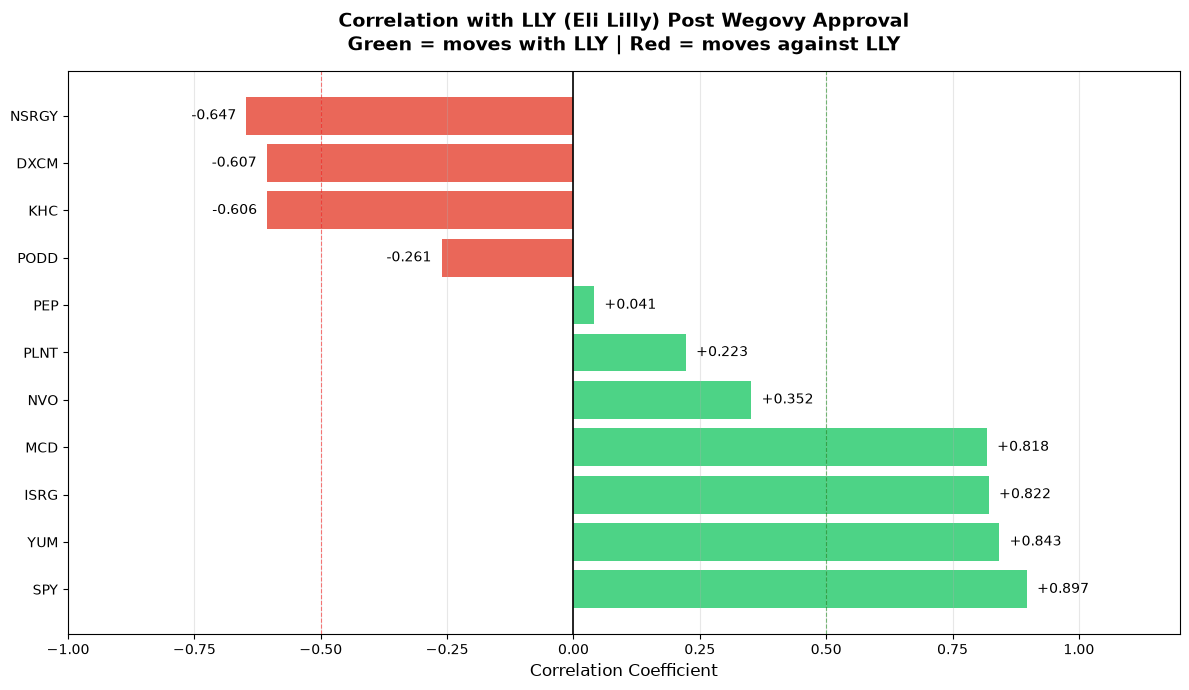

Correlation chart saved!


In [21]:
correlation_matrix = normalised.corr()
lly_correlation = correlation_matrix['LLY'].drop('LLY').sort_values(ascending=False)

print("=== CORRELATION WITH LLY (post Wegovy approval) ===")
print("(1.0 = moves in sync, 0 = no relationship, -1.0 = moves opposite)\n")

for ticker, corr in lly_correlation.items():
    sector = sector_map[ticker]
    bar = '█' * int(abs(corr) * 20)
    direction = '+' if corr > 0 else '-'
    print(f"{ticker:<6} {direction}{abs(corr):.3f}  {bar:<20}  [{sector}]")

# Save correlation chart
fig, ax = plt.subplots(figsize=(12, 7))
colours = ['#2ecc71' if x > 0 else '#e74c3c' for x in lly_correlation.values]
bars = ax.barh(lly_correlation.index, lly_correlation.values, color=colours, alpha=0.85)

for bar, val in zip(bars, lly_correlation.values):
    ax.text(val + (0.02 if val > 0 else -0.02), bar.get_y() + bar.get_height()/2,
            f'{val:+.3f}', va='center',
            ha='left' if val > 0 else 'right', fontsize=10)

ax.axvline(x=0, color='black', linewidth=1.2)
ax.axvline(x=0.5, color='green', linewidth=0.8, linestyle='--', alpha=0.5)
ax.axvline(x=-0.5, color='red', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_title('Correlation with LLY (Eli Lilly) Post Wegovy Approval\nGreen = moves with LLY | Red = moves against LLY',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Correlation Coefficient', fontsize=12)
ax.set_xlim(-1, 1.2)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
corr_path = os.path.join(project_root, 'visualizations', 'lly_correlation.png')
plt.savefig(corr_path, dpi=150, bbox_inches='tight')
plt.show()
print("Correlation chart saved!")

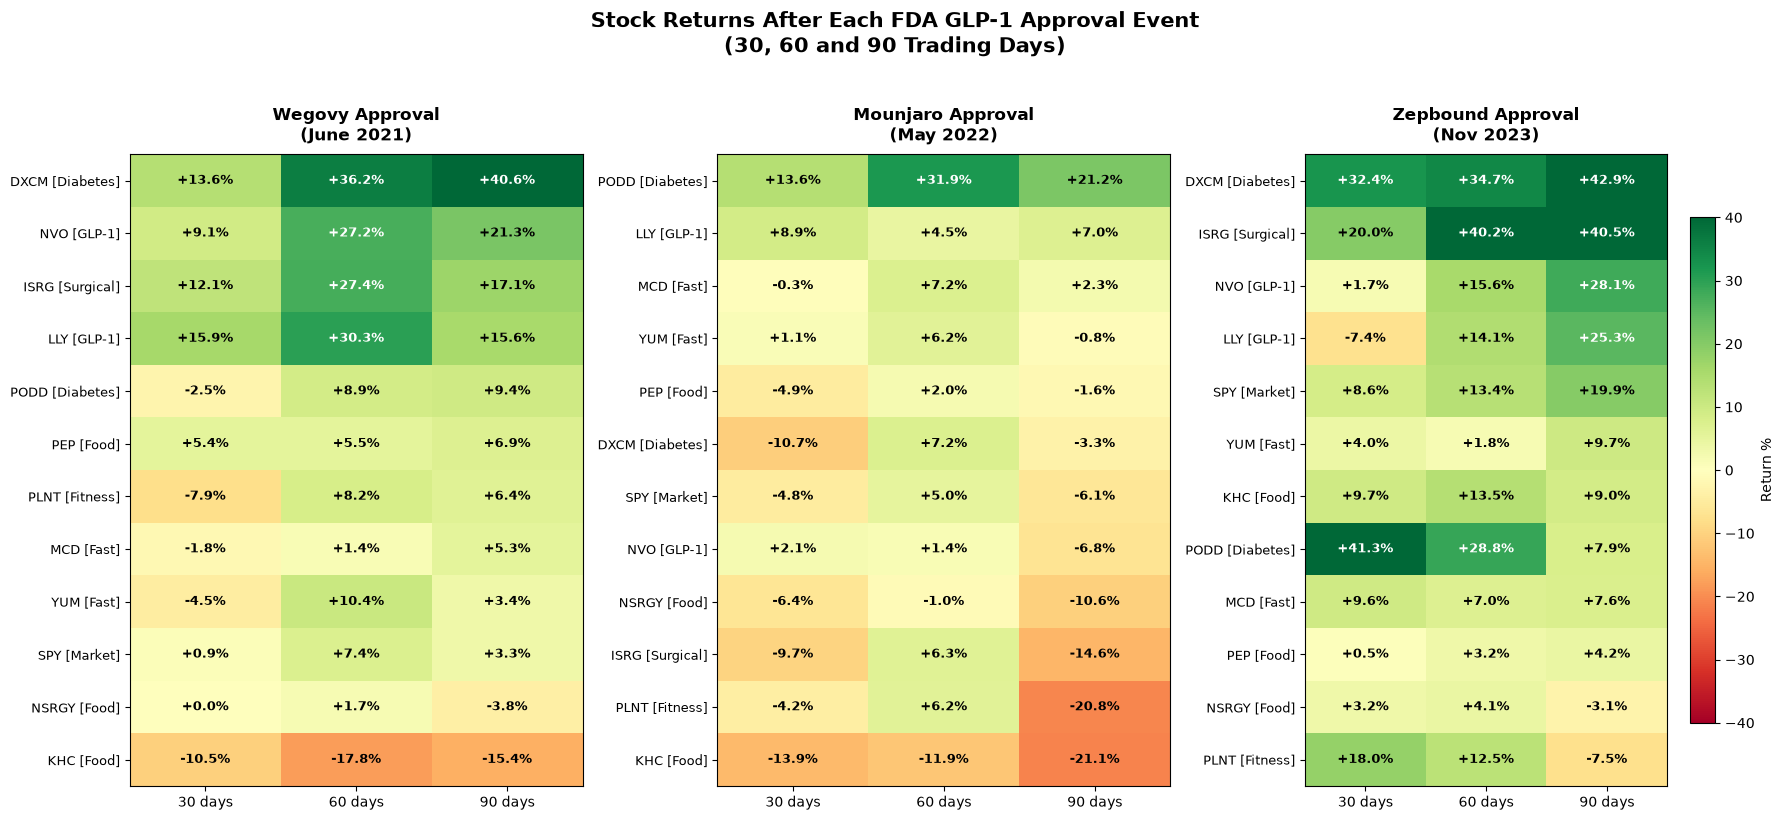

Heatmap saved!


In [22]:
def calculate_returns(prices, start_date, days):
    start_idx = prices.index.searchsorted(pd.Timestamp(start_date))
    end_idx = min(start_idx + days, len(prices) - 1)
    start_price = prices.iloc[start_idx]
    end_price = prices.iloc[end_idx]
    return ((end_price - start_price) / start_price * 100).round(2)

results = []
for event_name, event_date in events.items():
    for days, label in [(30, '30d'), (60, '60d'), (90, '90d')]:
        returns = calculate_returns(all_prices, event_date, days)
        for ticker, ret in returns.items():
            results.append({
                'event': event_name,
                'ticker': ticker,
                'sector': sector_map[ticker],
                'window': label,
                'return_pct': ret
            })

returns_df = pd.DataFrame(results)

# Save returns data
processed_path = os.path.join(project_root, 'data', 'processed')
os.makedirs(processed_path, exist_ok=True)
returns_df.to_csv(os.path.join(processed_path, 'event_returns.csv'), index=False)

# Build heatmap
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

event_titles = {
    'wegovy_approved':   'Wegovy Approval\n(June 2021)',
    'mounjaro_approved': 'Mounjaro Approval\n(May 2022)',
    'zepbound_approved': 'Zepbound Approval\n(Nov 2023)'
}

for ax, (event, title) in zip(axes, event_titles.items()):
    event_data = returns_df[returns_df['event'] == event].pivot(
        index='ticker', columns='window', values='return_pct'
    )[['30d', '60d', '90d']]
    event_data = event_data.sort_values('90d', ascending=False)

    im = ax.imshow(event_data.values, cmap='RdYlGn', aspect='auto', vmin=-40, vmax=40)

    for i in range(len(event_data.index)):
        for j in range(len(event_data.columns)):
            val = event_data.values[i, j]
            ax.text(j, i, f'{val:+.1f}%', ha='center', va='center',
                   fontsize=9, fontweight='bold',
                   color='black' if abs(val) < 25 else 'white')

    ax.set_xticks(range(3))
    ax.set_xticklabels(['30 days', '60 days', '90 days'], fontsize=10)
    ax.set_yticks(range(len(event_data.index)))
    ax.set_yticklabels([f"{t} [{sector_map[t].split()[0]}]"
                        for t in event_data.index], fontsize=9)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)

plt.colorbar(im, ax=axes[-1], label='Return %', shrink=0.8)
fig.suptitle('Stock Returns After Each FDA GLP-1 Approval Event\n(30, 60 and 90 Trading Days)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()

heatmap_path = os.path.join(project_root, 'visualizations', 'event_returns_heatmap.png')
plt.savefig(heatmap_path, dpi=150, bbox_inches='tight')
plt.show()
print("Heatmap saved!")